# Lab 2 — Imbalance Analysis

**Day 06 · Anomaly Detection · Cisco AI/ML Training**

---

> **Quick check:** imbalance **99:1** · baseline accuracy **0.99** · baseline F1 (fraud) = **0.00**




## Why this matters <!-- cisco-doc-enrich-2026 -->

**99:1 imbalance** makes 99% accuracy meaningless — the model can predict "not fraud" always.
Always inspect precision/recall on the minority class.

```
1000 rows:  990 legit  |  10 fraud
always predict 0  -->  accuracy 99%  but  F1_fraud = 0
```


## The accuracy trap

With **1%** fraud, always predicting legit yields **99%** accuracy but **0** fraud detections.

In [1]:
%matplotlib inline

from pathlib import Path

GH_ROOT = Path.cwd().resolve()
if GH_ROOT.name == "notebooks":
    GH_ROOT = GH_ROOT.parents[2]
elif (GH_ROOT.parent / "notebooks").is_dir() and (GH_ROOT.parents[1] / "requirements-student.txt").is_file():
    GH_ROOT = GH_ROOT.parents[1]
else:
    for parent in [GH_ROOT, *GH_ROOT.parents]:
        if (parent / "requirements-student.txt").is_file():
            GH_ROOT = parent
            break

# cisco-output-ready
print(f"Setup OK — repo root: {GH_ROOT}")


Setup OK — repo root: C:\25-Trainings\2-Confirmed\10-June-26-AI-ML-Cisco\GH


**Step 2** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

NUMERIC_FEATURES = ["amount", "distance_from_home"]
CATEGORICAL_FEATURES = ["merchant_category"]

df = pd.read_csv(GH_ROOT / "data" / "credit-card" / "credit_card_transactions.csv")
X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df["is_fraud"]

fraud_count = int(y.sum())
legit_count = len(y) - fraud_count
imbalance_ratio = legit_count / max(fraud_count, 1)

# cisco-debug-summary
print(f"Loaded {len(df):,} rows x {df.shape[1]} columns")
print("dtypes:", df.dtypes.to_dict())

Loaded 1,000 rows x 6 columns
dtypes: {'transaction_id': dtype('O'), 'timestamp': dtype('O'), 'amount': dtype('float64'), 'merchant_category': dtype('O'), 'distance_from_home': dtype('float64'), 'is_fraud': dtype('int64')}


**Step 3** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [3]:
print("Lab 2 — Imbalance analysis")
print(f"total rows: {len(y)}")
print(f"fraud: {fraud_count}, legit: {legit_count}")
print(f"imbalance ratio (legit:fraud): {imbalance_ratio:.1f}:1")
print(f"fraud rate: {y.mean():.4f}")

Lab 2 — Imbalance analysis
total rows: 1000
fraud: 10, legit: 990
imbalance ratio (legit:fraud): 99.0:1
fraud rate: 0.0100


## Class distribution

C:\Users\PC\AppData\Local\Temp\ipykernel_24788\2249727950.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index.map({0: "legit", 1: "fraud"}), y=counts.values, ax=ax, palette="Set2")


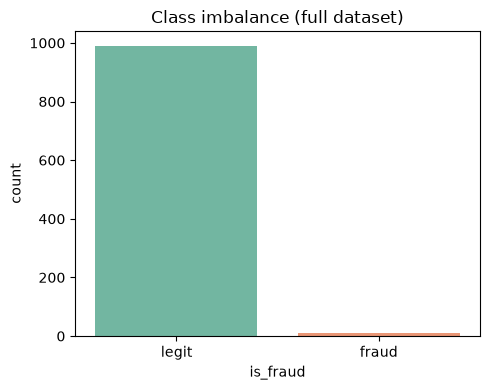

Value counts — long tail categories may be omitted.


In [4]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = y.value_counts().sort_index()
sns.barplot(x=counts.index.map({0: "legit", 1: "fraud"}), y=counts.values, ax=ax, palette="Set2")
ax.set_ylabel("count")
ax.set_title("Class imbalance (full dataset)")
plt.tight_layout()
plt.show()


# cisco-debug-summary
print("Value counts — long tail categories may be omitted.")

## Stratified train/test split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"train: {len(X_train)} (fraud {int(y_train.sum())})")
print(f"test:  {len(X_test)} (fraud {int(y_test.sum())})")

# cisco-debug-summary
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Positive rate — train: {y_train.mean():.2%} | test: {y_test.mean():.2%}")

train: 800 (fraud 8)
test:  200 (fraud 2)
Train: 800 | Test: 200
Positive rate — train: 1.00% | test: 1.00%


**Step 2** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [6]:
split_summary = pd.DataFrame({
    "split": ["train", "test"],
    "total": [len(y_train), len(y_test)],
    "fraud": [int(y_train.sum()), int(y_test.sum())],
    "legit": [int((y_train == 0).sum()), int((y_test == 0).sum())],
})
display(split_summary)

,split,total,fraud,legit
0,train,800,8,792
1,test,200,2,198


## Majority-class baseline

In [7]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ]
)

**Step 2** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [8]:
baseline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("clf", DummyClassifier(strategy="most_frequent")),
    ]
)
baseline.fit(X_train, y_train)
y_pred = baseline.predict(X_test)

baseline_acc = (y_pred == y_test).mean()
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"baseline accuracy (majority class): {baseline_acc:.4f}")
print(f"baseline F1 (fraud): {f1:.4f}")
print(f"unique predictions: {sorted(set(y_pred.tolist()))}")

baseline accuracy (majority class): 0.9900
baseline F1 (fraud): 0.0000
unique predictions: [0]


## Classification report

In [9]:
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       198
           1       0.00      0.00      0.00         2

    accuracy                           0.99       200
   macro avg       0.49      0.50      0.50       200
weighted avg       0.98      0.99      0.99       200



## Metrics cheat sheet

In [10]:
metrics_help = pd.DataFrame({
    "metric": ["accuracy", "precision (fraud)", "recall (fraud)", "F1 (fraud)"],
    "baseline": [f"{baseline_acc:.4f}", "0.00", "0.00", f"{f1:.4f}"],
    "higher_better": ["yes", "yes", "yes", "yes"],
    "use_when": [
        "balanced classes only",
        "false alarms costly",
        "missing fraud costly",
        "balance precision & recall",
    ],
})
display(metrics_help)


,metric,baseline,higher_better,use_when
0,accuracy,0.9900,yes,balanced classes only
1,precision (fraud),0.00,yes,false alarms costly
2,recall (fraud),0.00,yes,missing fraud costly
3,F1 (fraud),0.0000,yes,balance precision & recall


### Imbalance prompt 1

Show fraud rate in train and test.

In [11]:
print({'train': round(y_train.mean(),4), 'test': round(y_test.mean(),4)})

{'train': np.float64(0.01), 'test': np.float64(0.01)}


### Imbalance prompt 2

Count predictions per class.

In [12]:
print(pd.Series(y_pred).value_counts().to_dict())

# cisco-debug-summary
print("Value counts — long tail categories may be omitted.")

{0: 200}
Value counts — long tail categories may be omitted.


### Imbalance prompt 3

Compute confusion-style counts manually.

In [13]:
tp = int(((y_pred==1)&(y_test==1)).sum()); print({'tp': tp, 'fn': int(y_test.sum())-tp})

{'tp': 0, 'fn': 2}


### Imbalance prompt 4

Display class weights intuition.

In [14]:
print({'legit': legit_count, 'fraud': fraud_count, 'ratio': round(imbalance_ratio,1)})

{'legit': 990, 'fraud': 10, 'ratio': 99.0}


### Imbalance prompt 5

Plot fraud rate bar.

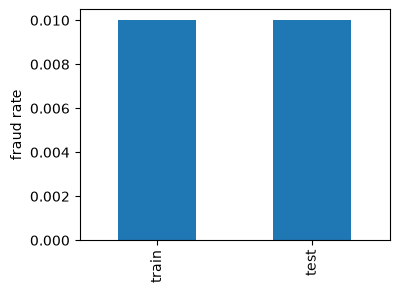

In [15]:
rates = pd.Series({'train': y_train.mean(), 'test': y_test.mean()}); ax = rates.plot(kind='bar', figsize=(4,3)); ax.set_ylabel('fraud rate');

### Imbalance prompt 6

List unique merchant categories in train.

In [16]:
print(sorted(X_train['merchant_category'].unique())[:8])

['electronics', 'gas', 'grocery', 'online_retail', 'pharmacy', 'restaurant', 'travel']


### Imbalance prompt 7

Show mean amount by class in train.

In [17]:
tmp = X_train.copy(); tmp['is_fraud']=y_train.values; print(tmp.groupby('is_fraud')['amount'].mean().round(2).to_dict())

# cisco-debug-summary
print("Groupby complete — compare categories in the table above.")

{0: 42.99, 1: 222.89}
Groupby complete — compare categories in the table above.


### Imbalance prompt 8

Show mean distance by class in train.

In [18]:
print(tmp.groupby('is_fraud')['distance_from_home'].mean().round(2).to_dict())

# cisco-debug-summary
print("Groupby complete — compare categories in the table above.")

{0: 5.09, 1: 34.73}
Groupby complete — compare categories in the table above.


### Imbalance prompt 9

Check baseline predicted probabilities shape.

In [19]:
print(baseline.predict_proba(X_test).shape)

(200, 2)


### Imbalance prompt 10

Verify baseline always predicts 0.

In [20]:
print(set(y_pred.tolist()))

{0}


### Imbalance prompt 11

Compute legit accuracy contribution.

In [21]:
print(round((y_test==0).mean(), 4))

0.99


### Imbalance prompt 12

Summarize why F1 is zero.

In [22]:
print('F1=0 because precision and recall for fraud are both 0.')

F1=0 because precision and recall for fraud are both 0.


### Imbalance prompt 13

Compare accuracy vs fraud recall.

In [23]:
print({'accuracy': round(baseline_acc,4), 'fraud_recall': 0.0})

{'accuracy': np.float64(0.99), 'fraud_recall': 0.0}


### Imbalance prompt 14

Display train fraud indices count.

In [24]:
print(int(y_train.sum()))

8


### Imbalance prompt 15

Display test fraud indices count.

In [25]:
print(int(y_test.sum()))

2


### Imbalance prompt 16

Recompute imbalance ratio.

In [26]:
print(round((y==0).sum()/max(y.sum(),1), 1))

99.0


### Imbalance prompt 17

Show first 5 test labels.

In [27]:
print(y_test.head().tolist())

[0, 0, 0, 0, 0]


### Imbalance prompt 18

Show first 5 baseline predictions.

In [28]:
print(y_pred[:5].tolist())

[0, 0, 0, 0, 0]


### Imbalance prompt 19

State business risk framing.

In [29]:
print('Missed fraud often costs more than false alarms in payments.')

Missed fraud often costs more than false alarms in payments.


### Imbalance prompt 20

Bridge to resampling.

In [30]:
print('Lab 3 oversamples minority fraud on train only.')

Lab 3 oversamples minority fraud on train only.


### Lab 2 quick recap 1

Pause and summarize one takeaway from the previous cell before moving on.

In [31]:
print("Lab 2 recap step 1: completed")

Lab 2 recap step 1: completed


### Lab 2 quick recap 2

Pause and summarize one takeaway from the previous cell before moving on.

In [32]:
print("Lab 2 recap step 2: completed")

Lab 2 recap step 2: completed


### Lab 2 quick recap 3

Pause and summarize one takeaway from the previous cell before moving on.

In [33]:
print("Lab 2 recap step 3: completed")

Lab 2 recap step 3: completed


### Lab 2 quick recap 4

Pause and summarize one takeaway from the previous cell before moving on.

In [34]:
print("Lab 2 recap step 4: completed")

Lab 2 recap step 4: completed

## Final checkpoint

In [35]:
assert fraud_count == 10
assert abs(imbalance_ratio - 99.0) < 0.1
assert abs(baseline_acc - 0.99) < 0.01
assert f1 == 0.0
assert int(y_test.sum()) == 2
print("Numbers match — you're good.")



Numbers match — you're good.


## Reflection

Why is accuracy misleading when fraud is 1% of rows?